In [157]:
import utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ot
import experiment

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
points, faces = utils.sampled_verts_from_random_action(return_faces = True, n_points = 1000)
utils.plot_median_skeleton(points, faces, connect_dist = 1)

Randomly chosen file: male_walk_turn_left_90.npz
Randomly chosen index: 234


In [55]:
points1, faces1 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 0, return_faces = True, n_points = 1000)
points2, faces2 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 10, return_faces = True, n_points = 1000)

In [56]:
M = ot.dist(points1, points2)
a = np.ones(1000) / 1000
b = np.ones(1000) / 1000
D = experiment.graph_distance_between_clouds_minimally_connected(points1 - points1.mean(axis = 0), points2 - points2.mean(axis = 0))
G1 = ot.solve(M, a, b).plan
G2 = ot.solve(M + D, a, b).plan
G3 = ot.solve(D, a, b).plan
print("G1", utils.region_accuracy_adjusted(G1, faces1, faces2))
print("G2", utils.region_accuracy_adjusted(G2, faces1, faces2))
print("G3", utils.region_accuracy_adjusted(G3, faces1, faces))

G1 0.7894736842105263
G2 0.8114035087719298
G3 0.1054897739504844


In [57]:
utils.plot_median_skeleton_from_match(G2, points1, points2, faces1, faces2, plot_ground_truth=True)

In [58]:
utils.plot_3d_points_and_connections_region_matched(points1 - points1.mean(axis = 0), points2 - points2.mean(axis = 0), faces1, faces2, G2)

Region accuracy adjusted: 0.8114035087719298


In [59]:
def pca_symmetry_plane(points, zero_z_coord = True):
    centered = points - points.mean(axis=0)
    C = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(C)
    normal = eigvecs[:, np.argmin(eigvals)]
    out = normal / np.linalg.norm(normal)
    if not zero_z_coord:
        return out
    if zero_z_coord:
        return np.array([out[0], out[1], 0])

import numpy as np
import plotly.express as px
import plotly.graph_objects as go

def plot_symmetry_plane(
    points,
    mean_point,
    normal,
    plane_size=1.0,
    show_plane=True
):
    """
    Plots a 3D point cloud with the symmetry plane and its normal.

    Parameters
    ----------
    points : (N,3) ndarray
        Point cloud
    mean_point : (3,) ndarray
        Point on the plane (usually the mean)
    normal : (3,) ndarray
        Plane normal (will be normalized)
    plane_size : float
        Controls the visual extent of the plane
    show_plane : bool
        Whether to render the plane surface
    """

    points = np.asarray(points)
    mean_point = np.asarray(mean_point)
    normal = normal / np.linalg.norm(normal)

    # --- Point cloud ---
    fig = px.scatter_3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        opacity=0.6
    )

    # --- Mean point ---
    fig.add_trace(
        go.Scatter3d(
            x=[mean_point[0]],
            y=[mean_point[1]],
            z=[mean_point[2]],
            mode="markers",
            marker=dict(size=6, color="red"),
            name="Mean"
        )
    )

    # --- Normal direction (line) ---
    t = np.linspace(-plane_size, plane_size, 2)
    line = mean_point + np.outer(t, normal)

    fig.add_trace(
        go.Scatter3d(
            x=line[:, 0],
            y=line[:, 1],
            z=line[:, 2],
            mode="lines",
            line=dict(width=6, color="black"),
            name="Normal"
        )
    )

    # --- Plane surface ---
    if show_plane:
        # Construct two orthonormal directions spanning the plane
        if abs(normal[2]) < 0.9:
            v1 = np.cross(normal, [0, 0, 1])
        else:
            v1 = np.cross(normal, [0, 1, 0])

        v1 /= np.linalg.norm(v1)
        v2 = np.cross(normal, v1)

        grid = np.linspace(-plane_size, plane_size, 10)
        xx, yy = np.meshgrid(grid, grid)

        plane_pts = (
            mean_point[:, None, None]
            + v1[:, None, None] * xx
            + v2[:, None, None] * yy
        )

        fig.add_trace(
            go.Surface(
                x=plane_pts[0],
                y=plane_pts[1],
                z=plane_pts[2],
                opacity=0.3,
                showscale=False,
                name="Symmetry plane"
            )
        )

    fig.update_layout(
        scene=dict(
            aspectmode="data"
        ),
        title="Point Cloud with Symmetry Plane and Normal"
    )

    fig.show()

import numpy as np

def stretch_away_from_plane(points, normal, stretch_factor=2.0):
    """
    Stretches points away from a plane by amplifying the component
    orthogonal to the plane.

    Parameters
    ----------
    points : (N,3) ndarray
        Input point cloud (assumed centered already)
    normal : (3,) ndarray
        Plane normal (z can be zeroed out beforehand)
    stretch_factor : float
        Factor by which distances from the plane are amplified

    Returns
    -------
    stretched_points : (N,3) ndarray
        Transformed point cloud
    """

    points = np.asarray(points)
    mean = points.mean(axis = 0)
    centered_points = points - mean
    normal = np.asarray(normal, dtype=float)

    # Normalize normal
    normal = normal / np.linalg.norm(normal)

    # Perpendicular component (distance from plane)
    perp = (centered_points @ normal)[:, None] * normal

    # Parallel component (lies in plane)
    parallel = centered_points - perp

    # Stretch away from plane
    stretched_points =  parallel + stretch_factor * perp

    return stretched_points + mean

def lift_with_symmetry(points, normal, beta=5.0):
    normal = normal / np.linalg.norm(normal)
    signed_dist = points @ normal
    return np.hstack([points, beta * signed_dist[:, None]])



In [60]:
points1, faces1 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 0, return_faces = True, n_points = 1000)
points2, faces2 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 10, return_faces = True, n_points = 1000)

In [61]:
normal1 = pca_symmetry_plane(points1)
normal2 = pca_symmetry_plane(points2)

for factor in np.arange(0, 2, 0.1):
    stretched_points1 = stretch_away_from_plane(points1, normal1, stretch_factor= factor)
    stretched_points2 = stretch_away_from_plane(points2, normal2, stretch_factor= factor)

    M = ot.dist(stretched_points1, stretched_points2)
    a = np.ones(1000) / 1000
    b = np.ones(1000) / 1000
    D = experiment.graph_distance_between_clouds_minimally_connected(stretched_points1 - stretched_points1.mean(axis = 0), stretched_points2 - stretched_points2.mean(axis = 0))
    G1 = ot.solve(M, a, b).plan
    G2 = ot.solve(M + D, a, b).plan
    G3 = ot.solve(D, a, b).plan
    print("G2", utils.region_accuracy_adjusted(G2, faces1, faces2))

G2 0.35604395604395606
G2 0.4714285714285714
G2 0.6076923076923076
G2 0.6571428571428571
G2 0.7065934065934066
G2 0.7494505494505495
G2 0.7736263736263737
G2 0.7527472527472527
G2 0.7725274725274726
G2 0.8417582417582418
G2 0.8472527472527472
G2 0.8219780219780219
G2 0.7978021978021979
G2 0.8186813186813187
G2 0.7846153846153846
G2 0.7901098901098901
G2 0.7615384615384615
G2 0.7879120879120879
G2 0.7538461538461538
G2 0.7538461538461538


In [62]:
normal1 = pca_symmetry_plane(points1)
normal2 = pca_symmetry_plane(points2)

lifted_points1 = lift_with_symmetry(points1, normal1)
lifted_points2 = lift_with_symmetry(points2, normal2)

for beta in np.arange(0, 2, 0.1):

    lifted_points1 = lift_with_symmetry(points1, normal1, beta=beta)
    lifted_points2 = lift_with_symmetry(points2, normal2, beta=beta)

    M = ot.dist(lifted_points1, lifted_points2)
    a = np.ones(1000) / 1000
    b = np.ones(1000) / 1000
    mean_centered1 = lifted_points1 - lifted_points1.mean(axis = 0)
    mean_centered2 = lifted_points2 - lifted_points2.mean(axis = 0)
    D = experiment.graph_distance_between_clouds_minimally_connected(mean_centered1[:,:-1], mean_centered2[:,:-1])
    G1 = ot.solve(M, a, b).plan
    G2 = ot.solve(M + D, a, b).plan
    #G3 = ot.solve(D, a, b).plan
    print("G1", utils.region_accuracy_adjusted(G1, faces1, faces2))
    print("G2", utils.region_accuracy_adjusted(G2, faces1, faces2))

G2 0.8472527472527472
G2 0.8472527472527472
G2 0.8472527472527472
G2 0.8505494505494505
G2 0.8505494505494505
G2 0.8527472527472527
G2 0.8527472527472527
G2 0.8494505494505494
G2 0.8472527472527472
G2 0.8494505494505494
G2 0.8472527472527472
G2 0.8461538461538461
G2 0.8417582417582418
G2 0.8406593406593407
G2 0.8340659340659341
G2 0.8340659340659341
G2 0.8274725274725274
G2 0.8208791208791208
G2 0.8186813186813187
G2 0.8208791208791208


In [84]:


lifted_points1 = lift_with_symmetry(points1, normal1, beta=1)
lifted_points2 = lift_with_symmetry(points2, normal2, beta=1)

M = ot.dist(lifted_points1, lifted_points2)
a = np.ones(1000) / 1000
b = np.ones(1000) / 1000
mean_centered1 = lifted_points1 - lifted_points1.mean(axis = 0)
mean_centered2 = lifted_points2 - lifted_points2.mean(axis = 0)
D = experiment.graph_distance_between_clouds_minimally_connected(mean_centered1[:,:-1], mean_centered2[:,:-1])
G1 = ot.solve(M, a, b).plan
G2 = ot.solve(M + D, a, b).plan
G3 = ot.solve(D, a, b).plan
print("G1", utils.region_accuracy_adjusted(G1, faces1, faces2))
print("G2", utils.region_accuracy_adjusted(G2, faces1, faces2))
print("G3", utils.region_accuracy_adjusted(G3, faces1, faces2))
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, G2)

G1 0.7175824175824176
G2 0.8472527472527472
G3 0.7197802197802198
Region accuracy adjusted: 0.8472527472527472


In [90]:
points = utils.sampled_verts_from_random_action(n_points = 10000)
normals = utils.pca_symmetry_plane(points)
lifted = utils.lift_with_symmetry(points, normals)
utils.plot_arr(points, color = lifted[:,3])

Randomly chosen file: male_run_to_walk.npz
Randomly chosen index: 129


In [91]:
plot_symmetry_plane(points, points.mean(axis = 0), normals)

In [144]:
normal = pca_symmetry_plane(points)
if (((points - points.mean(axis = 0)) @ normal)[points[:,2] > np.percentile(points[:,2], 90)] > 0).mean() < 0.5:
    normal = - normal

In [150]:
sideways_normal = np.cross(normal, np.array([0,0,1]))
points @ sideways_normal

TrackedArray([-0.25490292,  0.10426502,  0.13241696, ..., -0.33423552,
              -0.15630969, -0.20910008], shape=(10000,))

In [152]:
utils.plot_arr(points, color = points @ sideways_normal, colorbar = True)

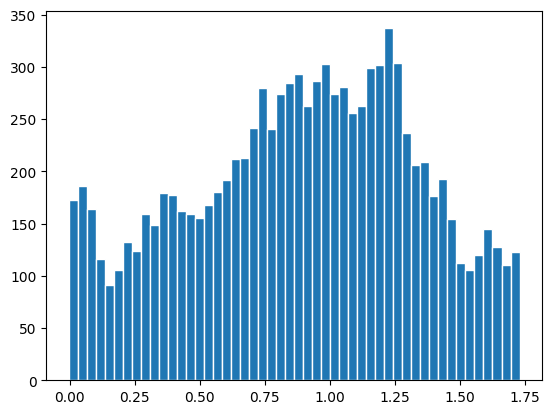

In [111]:
plt.hist(points[:,2], ec = "w", bins = 50)
plt.show()

In [160]:
utils.plot_arr(points1, color = utils.lift_with_symmetry(points1, normal1)[:,3])

i have changed


In [161]:
import os

In [227]:
while True:

    p = np.random.choice(os.listdir("datasets/action_smplx_models"))
    p = "female_run.npz"
    if p == "male2_Calibration_stageii.npz":
        print("picked calibration")
        continue
    idx = np.random.choice(range(int(np.load("datasets/action_smplx_models/" + p)["mocap_time_length"] * 120) - 70))

    points1, faces1 = utils.sampled_verts_from_path("datasets/action_smplx_models/" + p, idx = idx, n_points = 1000, return_faces = True)
    points2, faces2 = utils.sampled_verts_from_path("datasets/action_smplx_models/" + p, idx = idx + 50, n_points = 1000, return_faces = True)

    #normal1 = pca_symmetry_plane(points1)
    #normal2 = pca_symmetry_plane(points2)
    diff = points2.mean(axis = 0) - points1.mean(axis = 0)
    normal1 = np.median(points1[(points1[:,2] > np.percentile(points1[:,2], 90))], axis = 0) - np.median(points1, axis = 0)
    normal1 = np.array([normal1[0], normal1[2], 0])
    normal2 = np.median(points2[(points2[:,2] > np.percentile(points2[:,2], 90))], axis = 0) - np.median(points2, axis = 0)
    normal2 = np.array([normal2[0], normal2[2], 0])

    lifted_points1 = utils.lift_with_symmetry(points1, normal1, beta=1)
    lifted_points2 = utils.lift_with_symmetry(points2, normal2, beta=1)

    M = ot.dist(lifted_points1, lifted_points2)
    a = np.ones(1000) / 1000
    b = np.ones(1000) / 1000
    mean_centered1 = lifted_points1 - lifted_points1.mean(axis = 0)
    mean_centered2 = lifted_points2 - lifted_points2.mean(axis = 0)
    D = experiment.graph_distance_between_clouds_minimally_connected(mean_centered1[:,:-1], mean_centered2[:,:-1])

    G1 = ot.solve(M, a, b).plan
    G2 = ot.solve(M + D, a, b).plan

    G1acc = utils.region_accuracy_adjusted(G1, faces1, faces2)
    G2acc = utils.region_accuracy_adjusted(G2, faces1, faces2)

    if  G1acc > G2acc:
        print(G1acc)
        print(G2acc)
        break
    else:
        print("nope")

utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, G2)

nope
nope
0.3181818181818182
0.31493506493506496
Region accuracy adjusted: 0.31493506493506496


In [228]:
Gs = []

for i in np.arange(1, 11, 1):
    

    lifted_points1 = utils.lift_with_symmetry(points1, normal1, beta=i)
    lifted_points2 = utils.lift_with_symmetry(points2, normal2, beta=i)

    M = ot.dist(lifted_points1, lifted_points2)
    a = np.ones(1000) / 1000
    b = np.ones(1000) / 1000
    mean_centered1 = lifted_points1 - lifted_points1.mean(axis = 0)
    # mean_centered2 = lifted_points2 - lifted_points2.mean(axis = 0)
    # D = experiment.graph_distance_between_clouds_minimally_connected(mean_centered1[:,:-1], mean_centered2[:,:-1])

    G1 = ot.solve(M, a, b).plan
    Gs.append(G1)
    # G2 = ot.solve(M + D, a, b).plan

    G1acc = utils.region_accuracy_adjusted(G1, faces1, faces2)
    print(G1acc)
    # G2acc = utils.region_accuracy_adjusted(G2, faces1, faces2)

0.3181818181818182
0.3008658008658009
0.2748917748917749
0.262987012987013
0.23593073593073594
0.22835497835497837
0.21428571428571427
0.21536796536796537
0.21103896103896103
0.20454545454545456


In [225]:
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, Gs[2])

Region accuracy adjusted: 0.5540254237288136


In [ ]:
np.median(points1[(points1[:,2] > np.percentile(points1[:,2], 90))], axis = 0) - np.median(points1, axis = 0)

TrackedArray([-0.0634286 , -0.04781231,  1.56508005])

In [213]:
normal2

TrackedArray([-0.03912441,  0.0026366 , -0.01275613])

In [214]:
normal1

TrackedArray([-0.10739325,  0.08384446,  0.56070608])

In [218]:
plot_symmetry_plane(points1, points1.mean(axis = 0), normal1)

In [219]:
plot_symmetry_plane(points2, points2.mean(axis = 0), normal2)

In [229]:
normal1 = np.median(points1[(points1[:,2] > np.percentile(points1[:,2], 90))], axis = 0) - np.median(points1, axis = 0)
normal2 = np.median(points2[(points2[:,2] > np.percentile(points2[:,2], 90))], axis = 0) - np.median(points2, axis = 0)

combined = np.append(points1,points2,axis=0)
lifted1 = utils.lift_with_symmetry(points1, normal1)
lifted2 = utils.lift_with_symmetry(points2, normal2)
combined_dists = np.append(lifted1,lifted2,axis=0)

utils.plot_arr(combined, combined_dists[:,3], colorbar = True)

In [242]:
med1 = np.median(points2, axis = 0).reshape(-1, 3)
med2 = np.median(points2[(points2[:,2] > np.percentile(points2[:,2], 95))], axis = 0).reshape(-1, 3)
with_med1 = np.append(points2, med1, axis = 0)
with_med2 = np.append(with_med1, med2, axis = 0)
with_direc = np.append(with_med2, med1 + np.array([(med2 - med1)[0, 0], (med2-med1)[0,1], 0]), axis = 0)
utils.plot_arr(with_direc, color = ["gray"] * 1000 + ["red"] * 2 + ["green"])

In [279]:
print(((pc - pc.mean(axis = 0)) @ direc).shape)

(1000,)


Randomly chosen file: female_run_to_walk.npz
Randomly chosen index: 387
1.0242914979757085


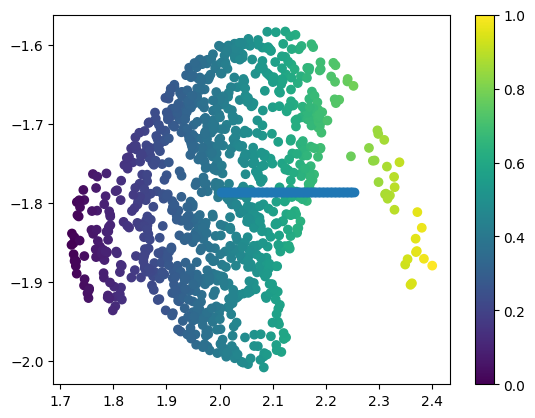

In [296]:
best_ratio_dist = float("inf")
best_theta = 0
pc = utils.sampled_verts_from_random_action()
for theta in np.arange(0, np.pi+ 0.01, 0.01):
    theta = 0
    direc = np.array([np.cos(theta), np.sin(theta), 0]) / 4
    withmean = np.append(pc, pc.mean(axis = 0).reshape(-1, 3), axis = 0)
    withdirec = np.append(withmean, pc.mean(axis = 0).reshape(-1, 3) + direc.reshape(-1, 3), axis = 0)
    signed_dists =  (pc - pc.mean(axis = 0)) @ direc
    num_neg = (signed_dists <= 0).sum()
    num_pos = (signed_dists > 0).sum()
    ratio = num_neg / num_pos
    rat_dist = np.abs(ratio - 1)
    if rat_dist < best_ratio_dist:
        best_theta = theta
        best_ratio_dist = rat_dist
print(ratio)
plt.scatter(pc[:,0], pc[:,1], c =  (pc - pc.mean(axis = 0)) @ direc)
plt.scatter(
    [k * direc[0] + pc.mean(axis = 0)[0] for k in np.arange(0, 1.01, 0.01)],
    [k * direc[1] + pc.mean(axis = 0)[1] for k in np.arange(0, 1.01, 0.01)]
)
plt.colorbar()

In [305]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

def plot_point_cloud_with_pca_axes(X, axis_length=None):
    """
    X: (N, 3) numpy array
    axis_length: length of PCA direction lines (auto-scaled if None)
    """
    X = np.asarray(X)

    # Median as center
    center = np.median(X, axis=0)
    Xc = X - center

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    axes = Vt  # rows = principal directions

    if axis_length is None:
        axis_length = 0.5 * np.max(np.linalg.norm(Xc, axis=1))

    # Point cloud
    fig = px.scatter_3d(
        x=X[:, 0],
        y=X[:, 1],
        z=X[:, 2],
        opacity=0.6,
    )

    colors = ["red", "green", "blue"]

    # PCA axes as lines
    for i in range(3):
        direction = axes[i]
        line_end = center + axis_length * direction

        fig.add_trace(
            go.Scatter3d(
                x=[center[0], line_end[0]],
                y=[center[1], line_end[1]],
                z=[center[2], line_end[2]],
                mode="lines",
                line=dict(width=6, color=colors[i]),
                name=f"PC{i+1}",
            )
        )

    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        legend_title_text="PCA Axes",
    )

    fig.show()


In [356]:
points = pc
head_mean = points[
                (points[:,2] > np.percentile(points[:,2], 92.5) )
                & (np.linalg.norm((points - points.mean(axis = 0))[:,:-1], axis = 1) < .2)
            ].mean(axis = 0)
diff = (head_mean - points.mean(axis = 0)) / np.linalg.norm(head_mean - points.mean(axis = 0))
head_normal = np.array([diff[0], diff[1], 0])
head_normal = head_normal / np.linalg.norm(head_normal)

In [357]:
wm = np.append(points, points.mean(axis = 0).reshape(-1, 3), axis = 0)
wd = np.append(wm, (points.mean(axis = 0) + head_normal).reshape(-1, 3), axis = 0)
utils.plot_arr(wd, color = ["blue"] * 1000 + ["red"] + ["green"])

In [362]:
#utils.plot_arr(points, color = (points - points.mean(axis = 0)) @ np.cross(head_normal, np.array([0,0,1])), colorbar = True)
utils.plot_arr(points, color = (points - points.mean(axis = 0)) @ np.cross(utils.pca_symmetry_plane(points), np.array([0,0,1])), colorbar = True)


In [369]:
np.append(points, (points - points.mean(axis = 0)) @ np.cross(head_normal, np.array([0,0,1])).reshape(-1, 1), axis =1)

array([[-0.15955492, -0.00492371,  0.14067871,  0.13731733],
       [-0.38197249,  0.05722198,  0.42884493, -0.09335826],
       [-0.1357222 , -0.0642146 ,  1.36397174,  0.17377343],
       ...,
       [-0.13199869,  0.0649837 ,  0.43586755,  0.14858793],
       [-0.99408694,  0.10558315,  1.51789016, -0.70084041],
       [-0.11020484,  0.08945886,  1.15906796,  0.16437411]],
      shape=(1000, 4))

In [ ]:
pc = utils.sampled_verts_from_random_action()
plot_point_cloud_with_pca_axes(pc[pc[:,2] > np.percentile(pc[:,2], 92.5)])

Randomly chosen file: male2_Calibration_stageii.npz
Randomly chosen index: 77


In [65]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def animate_median_skeleton(
    points_seq,
    faces_seq,
    width=600,
    height=1000,
    connect_dist=1,
    marker_size=10,
    line_width=2
):
    T = len(points_seq)

    # Handle static vs dynamic faces
    dynamic_faces = isinstance(faces_seq, (list, tuple, np.ndarray)) and len(faces_seq) == T

    frames = []

    for t in range(T):
        points = points_seq[t]
        faces = faces_seq[t] if dynamic_faces else faces_seq

        regions = utils.faces_to_regions(faces)

        df = pd.DataFrame({
            "x": points[:, 0],
            "y": points[:, 1],
            "z": points[:, 2],
            "regions": regions
        })

        grouped = df.groupby("regions").median()
        median_points = grouped.to_numpy()

        traces = []

        # Median joint markers
        traces.append(go.Scatter3d(
            x=median_points[:, 0],
            y=median_points[:, 1],
            z=median_points[:, 2],
            mode="markers",
            marker=dict(size=marker_size),
            showlegend=False
        ))

        # Skeleton edges
        for i in range(len(utils.LABELS)):
            adjacents = [j for j in range(len(utils.LABELS)) if utils.D[i, j] == connect_dist]
            for adj in adjacents:
                traces.append(go.Scatter3d(
                    x=[median_points[i, 0], median_points[adj, 0]],
                    y=[median_points[i, 1], median_points[adj, 1]],
                    z=[median_points[i, 2], median_points[adj, 2]],
                    mode="lines",
                    line=dict(color="gray", width=line_width),
                    showlegend=False
                ))

        frames.append(go.Frame(data=traces, name=str(t)))

    # Initial frame
    fig = go.Figure(data=frames[0].data, frames=frames)

    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data"
        ),
        template="plotly_white",
        width=width,
        height=height,
        title="Animated Median Skeleton",
        scene_camera=dict(
            eye=dict(x=2.5, y=2.5, z=2.5)
        ),
        updatemenus=[{
            "type": "buttons",
            "showactive": False,
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [None, {
                        "frame": {"duration": 50, "redraw": True},
                        "transition": {"duration": 0},
                        "fromcurrent": True
                    }]
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [[None], {
                        "frame": {"duration": 0},
                        "mode": "immediate"
                    }]
                }
            ]
        }]
    )

    return fig


In [66]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def animate_median_skeleton_from_match(
    G_seq,
    points1_seq,
    points2_seq,
    faces1_seq,
    faces2_seq,
    plot_ground_truth=False,
    width=600,
    height=1000,
    connect_dist=1,
    marker_size=10,
    line_width=2
):
    T = len(G_seq)

    dynamic_faces1 = isinstance(faces1_seq, (list, tuple, np.ndarray)) and len(faces1_seq) == T
    dynamic_faces2 = isinstance(faces2_seq, (list, tuple, np.ndarray)) and len(faces2_seq) == T

    print(len(faces1_seq) == T)

    frames = []

    for t in range(T):
        G = G_seq[t]
        points1 = points1_seq[t]
        points2 = points2_seq[t]

        faces1 = faces1_seq[t] if dynamic_faces1 else faces1_seq
        faces2 = faces2_seq[t] if dynamic_faces2 else faces2_seq

        traces = []

        # -------------------------
        # MATCHED / ORDERED POINTS
        # -------------------------
        ordered_points = (G / G.max()) @ points2

        regions = utils.faces_to_regions(faces1)
        df = pd.DataFrame({
            "x": ordered_points[:, 0],
            "y": ordered_points[:, 1],
            "z": ordered_points[:, 2],
            "regions": regions
        })

        grouped = df.groupby("regions").median()
        matched_medians = grouped.to_numpy()

        # Matched markers
        traces.append(go.Scatter3d(
            x=matched_medians[:, 0],
            y=matched_medians[:, 1],
            z=matched_medians[:, 2],
            mode="markers",
            marker=dict(size=marker_size, color="red"),
            showlegend=False
        ))

        # Matched skeleton edges
        for i in range(len(utils.LABELS)):
            adjacents = [j for j in range(len(utils.LABELS)) if utils.D[i, j] == connect_dist]
            for adj in adjacents:
                traces.append(go.Scatter3d(
                    x=[matched_medians[i, 0], matched_medians[adj, 0]],
                    y=[matched_medians[i, 1], matched_medians[adj, 1]],
                    z=[matched_medians[i, 2], matched_medians[adj, 2]],
                    mode="lines",
                    line=dict(color="red", width=line_width),
                    showlegend=False
                ))

        # -------------------------
        # GROUND TRUTH (OPTIONAL)
        # -------------------------
        if plot_ground_truth:
            regions = utils.faces_to_regions(faces2)
            df = pd.DataFrame({
                "x": points2[:, 0],
                "y": points2[:, 1],
                "z": points2[:, 2],
                "regions": regions
            })

            grouped = df.groupby("regions").median()
            gt_medians = grouped.to_numpy()

            # GT markers
            traces.append(go.Scatter3d(
                x=gt_medians[:, 0],
                y=gt_medians[:, 1],
                z=gt_medians[:, 2],
                mode="markers",
                marker=dict(size=5, color="blue"),
                showlegend=False
            ))

            # GT skeleton edges
            for i in range(len(utils.LABELS)):
                adjacents = [j for j in range(len(utils.LABELS)) if utils.D[i, j] == connect_dist]
                for adj in adjacents:
                    traces.append(go.Scatter3d(
                        x=[gt_medians[i, 0], gt_medians[adj, 0]],
                        y=[gt_medians[i, 1], gt_medians[adj, 1]],
                        z=[gt_medians[i, 2], gt_medians[adj, 2]],
                        mode="lines",
                        line=dict(color="blue", width=line_width),
                        showlegend=False
                    ))

        frames.append(go.Frame(data=traces, name=str(t)))

    # Initial figure
    fig = go.Figure(data=frames[0].data, frames=frames)

    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data"
        ),
        template="plotly_white",
        title="Animated Median Skeleton From Match",
        width=width,
        height=height,
        scene_camera=dict(
            eye=dict(x=2.5, y=2.5, z=2.5)
        ),
        updatemenus=[{
            "type": "buttons",
            "showactive": False,
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [None, {
                        "frame": {"duration": 50, "redraw": True},
                        "transition": {"duration": 0},
                        "fromcurrent": True
                    }]
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [[None], {
                        "frame": {"duration": 0},
                        "mode": "immediate"
                    }]
                }
            ]
        }]
    )

    return fig


In [67]:
points_timeseries = []
faces_timeseries = []
normals_timeseries = []
lifted_timeseries = []
G_timeseries = []
regions_timeseries = []
num_frames = 10
frame_step = 5
for i in range(0, num_frames * frame_step + 1, frame_step):
    p, f = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = i, return_faces=True)
    points_timeseries.append(p)
    faces_timeseries.append(f)
    regions_timeseries.append([utils.LABEL_TO_INDEX[reg] for reg in utils.faces_to_regions(f)])
    normals_timeseries.append(pca_symmetry_plane(p))
    lifted_timeseries.append(lift_with_symmetry(p, normals_timeseries[-1], beta = 1))
    if i != 0:
        M = ot.dist(lifted_timeseries[0], lifted_timeseries[0])
        a = np.ones(1000) / 1000
        b = np.ones(1000) / 1000

        mean_centered1 = lifted_timeseries[0] - lifted_timeseries[0].mean(axis = 0)
        mean_centered2 = lifted_timeseries[-1] - lifted_timeseries[-1].mean(axis = 0)

        D = experiment.graph_distance_between_clouds_minimally_connected(mean_centered1[:,:-1], mean_centered2[:,:-1])

        G_timeseries.append(ot.solve(M + D, a, b).plan)
    print(i, "done")



0 done
5 done
10 done
15 done
20 done
25 done
30 done
35 done
40 done
45 done
50 done


In [68]:
G_arr = np.array(G_timeseries)
p0_arr = np.array(points_timeseries[:-1])
p_arr = np.array(points_timeseries[1:])
f0_arr = np.array([faces_timeseries[0]] * 10)
f_arr = np.array(faces_timeseries[1:])
animate_median_skeleton_from_match(G_arr, p0_arr, p_arr, f0_arr, f_arr, plot_ground_truth=True)

True


In [69]:
propagated_Gs = [np.eye(1000)]
for i in range(len(G_timeseries)):
    propagated_Gs.append((propagated_Gs[-1] / propagated_Gs[-1].max()) @ G_timeseries[i])

In [70]:
G_arr_prop = np.array(propagated_Gs)
p0_arr = np.array(points_timeseries[:-1])
p_arr = np.array(points_timeseries[1:])
f0_arr = np.array([(propagated_Gs[i] / propagated_Gs[i].max()) @ faces_timeseries[i] for i in range(len(propagated_Gs))]).astype(int)[:-1]
f_arr = np.array(faces_timeseries[1:])
animate_median_skeleton_from_match(G_arr_prop[1:], p0_arr, p_arr, f0_arr, f_arr, plot_ground_truth=True)

True


In [71]:
utils.faces_to_regions(f0_arr[0])

['right_shin',
 'right_thigh',
 'pelvis',
 'upper_torso',
 'right_shin',
 'right_foot',
 'head',
 'right_shin',
 'left_thigh',
 'lower_torso',
 'upper_torso',
 'right_thigh',
 'upper_torso',
 'right_forearm',
 'right_hand',
 'right_thigh',
 'head',
 'right_upper_arm',
 'left_hand',
 'right_shin',
 'right_upper_arm',
 'left_forearm',
 'right_shin',
 'right_thigh',
 'right_foot',
 'lower_torso',
 'left_thigh',
 'lower_torso',
 'right_shin',
 'pelvis',
 'left_shin',
 'pelvis',
 'left_shin',
 'right_upper_arm',
 'upper_torso',
 'upper_torso',
 'right_upper_arm',
 'left_shin',
 'right_shin',
 'left_upper_arm',
 'right_thigh',
 'right_forearm',
 'right_forearm',
 'right_thigh',
 'upper_torso',
 'head',
 'right_thigh',
 'left_upper_arm',
 'upper_torso',
 'pelvis',
 'left_upper_arm',
 'left_hand',
 'head',
 'left_foot',
 'left_shin',
 'pelvis',
 'head',
 'pelvis',
 'upper_torso',
 'upper_torso',
 'right_foot',
 'left_thigh',
 'right_upper_arm',
 'left_upper_arm',
 'pelvis',
 'lower_torso',
 'p

In [72]:
f0_arr

array([[ 7979, 18971, 18965, ..., 15091,  7092,  5764],
       [ 6251,  6040,  4912, ..., 15058, 17339, 15718],
       [ 6317, 18043,  1624, ...,  4945, 16830, 16877],
       ...,
       [ 3081,  4922, 16424, ...,  6180,  8080,  6571],
       [15974,  4226, 18566, ...,  1416, 18259,  6028],
       [ 5391, 12130,  7997, ...,  4943, 16638, 18656]], shape=(10, 1000))

In [73]:
for i in range(len(G_timeseries)):
    print(utils.region_accuracy_adjusted(G_timeseries[i], faces_timeseries[i], faces_timeseries[i + 1]))

0.6369426751592356
0.11075949367088607
0.1064516129032258
0.10355987055016182
0.0967741935483871
0.10845986984815618
0.1086021505376344
0.088016967126193
0.08342480790340286
0.09850107066381156


In [74]:
utils.plot_3d_points_and_connections_region_matched(points_timeseries[0], points_timeseries[-1], faces_timeseries[0], faces_timeseries[-1], G_timeseries[-1])

Region accuracy adjusted: 0.39107332624867164


In [75]:
np.load("datasets/action_smplx_models/male_run.npz")["mocap_time_length"] * 120

np.float64(326.0)